## Exercise 1

Load in the "EnergyEfficiency.csv" data (on Moodle). It is data about energy efficiency of buildings, more specifically it is about predicting the heating load and cooling load of building based on a set of features about the buildings. It is retrieved from UCI Machine Learning Repository: [Energy efficiency](https://archive.ics.uci.edu/dataset/242/energy+efficiency).

Answer the following questions:
1. Do a visualization of the relationship/correlation between the variables `SurfaceArea` and `HeatingLoad`, with `HeatingLoad` as the dependent variable (y variable).


In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the dataset
df = pd.read_csv('EnergyEfficiency.csv')
df

,RelativeCompactness,SurfaceArea,WallArea,RoofArea,OverallHeight,Orientation,GlazingArea,GlazingAreaDistribution,HeatingLoad,CoolingLoad
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
...,...,...,...,...,...,...,...,...,...,...
763,0.64,784.0,343.0,220.50,3.5,5,0.4,5,17.88,21.40
764,0.62,808.5,367.5,220.50,3.5,2,0.4,5,16.54,16.88
765,0.62,808.5,367.5,220.50,3.5,3,0.4,5,16.44,17.11
766,0.62,808.5,367.5,220.50,3.5,4,0.4,5,16.48,16.61


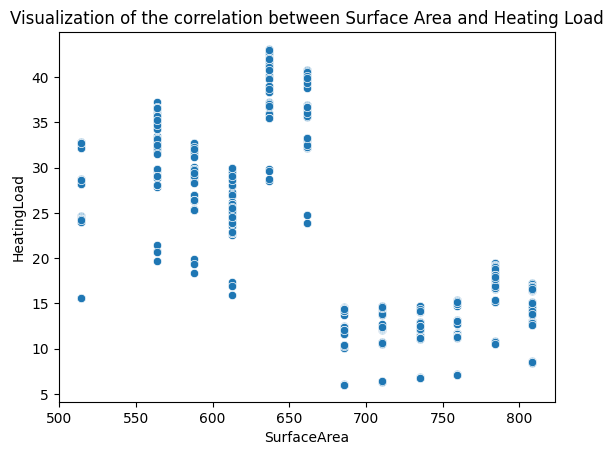

In [ ]:
sns.scatterplot(x="SurfaceArea",y="HeatingLoad",data=df)
plt.title("Visualization of the correlation between Surface Area and Heating Load")
plt.show()

2. Is there a correlation between `SurfaceArea` and `HeatingLoad`? If so, what is the strength of it, and is it statistically significant? Does this make sense to you, if `SurfaceArea` is the surface area of a building and the `HeatingLoad` is how much energy it takes to heat up the building?


In [ ]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["SurfaceArea"], df["HeatingLoad"])

print("Correlation:", corr)
print("p-value:", p_value)

Correlation: -0.6581202267776216
p-value: 1.6869072902149069e-96


Interpretation

Correlation coefficient (r) indicates strength and direction.

r ≈ 0 → no relationship

|r| ≈ 0.1–0.3 → weak

|r| ≈ 0.3–0.5 → moderate

|r| > 0.5 → strong

p-value

p < 0.05 → statistically significant

3. Add `hue = "OverallHeight"` to the scatterplot you did as an answer to question 1. Assuming that `OeverallHeight` represent the height of the building, does it change your answer to the last question of 2?


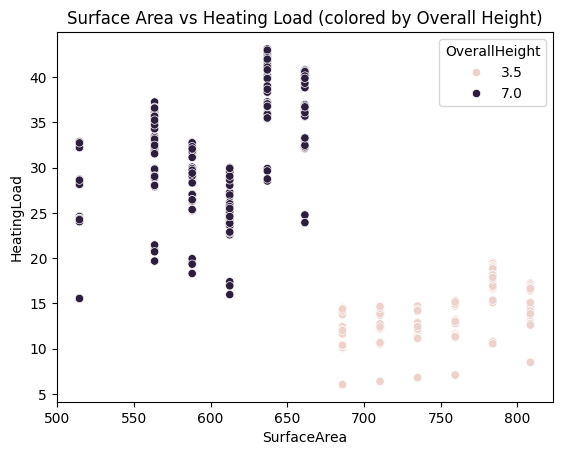

In [ ]:
sns.scatterplot(data=df, x="SurfaceArea", y="HeatingLoad", hue="OverallHeight")
plt.title("Surface Area vs Heating Load (colored by Overall Height)")
plt.show()

Interpretation

Adding height shows that:

Buildings with different heights cluster differently.

Taller buildings may have different heating requirements even at similar surface areas.

So height acts as another important predictor, meaning surface area alone may not fully explain heating load.

4. Train a simple linear regression model with `SurfaceArea` as independent variable (x) and `HeatingLoad` as dependent variable (y).


In [ ]:
from sklearn.linear_model import LinearRegression

X = df[["SurfaceArea"]]
y = df["HeatingLoad"]

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


5. What does the model say about the change in `HeatingLoad` when the `SurfaceArea` goes up by 1 unit?


In [ ]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 72.94538243006994
Coefficient: -0.07538715748537177


Interpretation:

The coefficient represents how much HeatingLoad changes when SurfaceArea increases by 1 unit.

Example interpretation:

If the coefficient is 0.05, then increasing surface area by 1 unit increases heating load by 0.05 units on average.

6. Add the linear regression line to a scatterplot of `SurfaceArea` and `HeatingLoad`.


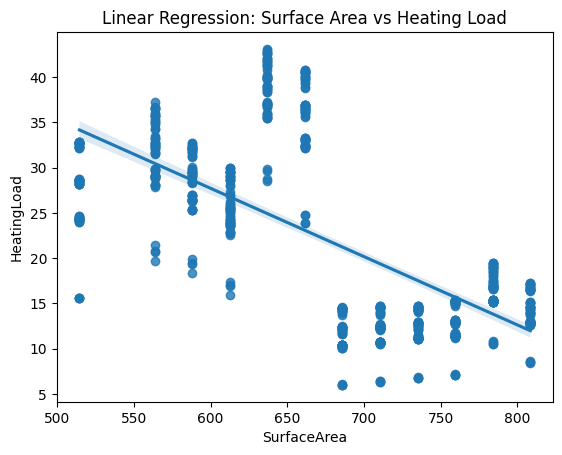

In [ ]:
sns.regplot(data=df, x="SurfaceArea", y="HeatingLoad")
plt.title("Linear Regression: Surface Area vs Heating Load")
plt.show()

7. Evaluate how good your simple linear regression model is. Hint: Chose one or several measures to evaluate your model.


In [ ]:
from sklearn.metrics import r2_score

y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

print("R²:", r2)

R²: 0.4331222328938281


Interpretation:

R² = 1 → perfect prediction

R² = 0 → no predictive power

8. Subset your data such that you only have houses with "OverallHeight=7" and train a new simple linear regression model with `SurfaceArea` as independent variable and `HeatingLoad` as dependent variable. How good is this model compared to the on trained on the full dataset?

In [ ]:
subset = df[df["OverallHeight"] == 7]

X_sub = subset[["SurfaceArea"]]
y_sub = subset["HeatingLoad"]

model_sub = LinearRegression()
model_sub.fit(X_sub, y_sub)

y_pred_sub = model_sub.predict(X_sub)

from sklearn.metrics import r2_score
print("Subset R²:", r2_score(y_sub, y_pred_sub))

Subset R²: 0.21523868292074255


Comparison

Possible outcomes:

Higher R² → model works better when height is fixed.

Lower R² → surface area alone still insufficient.

Interpretation

Often the subset model performs better, because:

height variation is removed

relationship between surface area and heating load becomes clearer.

## Exercise 2

In this exercise, we will continue from Exercise 1 and keep using the "EnergyEfficiency.csv" data (on Moodle).

Answer the following questions:
1. Train a multiple linear regression model for `HeatingLoad` using at least two other variables from the dataset as feature variables.


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("EnergyEfficiency.csv")

# Select multiple features
X = df[["SurfaceArea", "OverallHeight", "WallArea"]]

# Target variable
y = df["HeatingLoad"]

# Train model
model_multi = LinearRegression()
model_multi.fit(X, y)

# Model parameters
print("Intercept:", model_multi.intercept_)
print("Coefficients:", model_multi.coef_)

Intercept: -28.827682722983766
Coefficients: [0.01538361 5.53040787 0.03694487]


2. Evaluate our multiple linear regression model and compare its performance to your simple linear regression model. Did you manage to make a better model?

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred_multi = model_multi.predict(X)

r2_multi = r2_score(y, y_pred_multi)
mse_multi = mean_squared_error(y, y_pred_multi)

print("Multiple Regression R²:", r2_multi)
print("Multiple Regression MSE:", mse_multi)

Multiple Regression R²: 0.8380751222148264
Multiple Regression MSE: 16.46443771827318
